# Investigate the similarities between the templates for CUT2 (bdt_all > 0.35)

### Setting up the data and tools

In [1]:
# Importing the notebook with common setup 
%run 'bdt-all-common.ipynb'

Welcome to JupyROOT 6.28/00


Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903000") to load datasets
Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903003") to load dataset for double charm
Invoke  df_signal_23903000 = load_signal_from_inclMC() to load signal from 23903000 Inclusive MC
or
Invoke  df_signal = load_signal_all()
Invoke  df_background = load_background_category(category)


In [2]:
import seaborn as sn
plt.rcParams["figure.figsize"] = (15, 15)

## Applying  CUT1 i.e. BDT_all > 0.35

In [3]:
bdt_cutval=0.35

In [4]:
dfcut = df.query(f"bdt_all > {bdt_cutval}")
c = mygroupby(dfcut, 'category')
import categories4 as f
c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
c['simplified_name'] = c.apply(lambda row: f.detailed_to_simplified_category_mapping.get(row['name'], 'NA'), axis=1)
c

,category,count,Percentage,cumulative %,name,simplified_name
0,19,31571,26.030639,26.030639,Xc_signal_Ypis_displaced_fromB0_fromDp,doubleCharm
1,18,15907,13.115498,39.146136,Xc_signal_Ypis_displaced_fromBs_fromDs,doubleCharm
2,14,12554,10.350912,49.497048,Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB,doubleCharm
3,20,11754,9.691303,59.188351,Xc_signal_Ypis_displaced_fromBp_fromD0,doubleCharm
4,0,10106,8.332509,67.520860,Xc_background,Xc_background
5,22,9325,7.688566,75.209426,Xc_signal_Ypis_displaced_fromBs_fromDp,doubleCharm
6,7,6174,5.090531,80.299957,Xc_signal_Ypis_nomatch_doubleCharm,doubleCharm
7,24,5727,4.721975,85.021932,Xc_signal_Ypis_displaced_fromBs_fromTau,signal
8,23,4962,4.091224,89.113156,Xc_signal_Ypis_displaced_fromBp_fromDp,doubleCharm
9,25,2842,2.343260,91.456416,Xc_signal_Ypis_displaced_fromB0_fromD0,doubleCharm


There are 17 categories represented by more than 100 candidates

## Using the Kolmogorov-Smirnov test to see which distributions are similar

In [5]:
def find_clusters(m, threshold):
    allsets = set()
    for i in m.index:
        s = frozenset(m[m[i] > threshold][i].index)
        if s:
            allsets.add(s)
    return allsets

# Iterative
def merge_clusters(clusters):
    final = []
    tomerge = list(clusters)
    while True:
        h = tomerge[0]
        t = tomerge[1:]
        if not t:
            final.append(h)
            break
        tmp = []
        merged = False
        for c in t:
            if h & c:
                tmp.append( h | c)
                merged = True
            else:
                tmp.append(c)
        if not merged:
            final.append(h)
        tomerge = tmp
    return final

def merge_clusters_rec(unmerged, merged):
    """ Merge sets with non null intersection """
    h = unmerged[0]
    t = unmerged[1:]
    
    # End of recursion if ony one element in the list,nothing to merge to....
    if not t:
        merged.append(h)
        return t, merged
    
    # Iterate over the list of elements, comparing the first one h,
    # with all the others. If h has no intersection we add it to the
    # list of processed elements (merged), otherwise we merge it to the
    # element in common and we iterate the function again on the 
    # new list containing this new element plus the others
    tmp = []
    was_merged = False
    for c in t:
        if h & c:
            tmp.append( h | c)
            was_merged = True
        else:
            tmp.append(c)
    if not was_merged:
        merged.append(h)

    return merge_clusters_rec(tmp, merged)


def find_and_merge_clusters(m, threshold=0.5):
    clusters = find_clusters(m, threshold)
    unmerged, merged = merge_clusters_rec(list(clusters), [])
    return [ list(s) for s in merged ]


In [6]:
from scipy.stats import ks_2samp

def similar_categories(df, shown_number=17):
    """ Finding which categories have similar histograms for q2_2, tauY_2, bdt_all """
    
    # Grouping the samples per category
    c = mygroupby(df, 'category')
    c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
    
    # Preparing the list of categories to process
    #shown_number=17
    shown_categs = list(c.head(shown_number)['category'])
  
    # Building a list of detasets filtered 
    datasets = { f"{c}":  df.query(f"category == {c}") for c in shown_categs }
    datasets["others"] =  df.query(f"category not in {shown_categs}")
    datasets_names = [ f"{c}:" + categories[f"{c}"] for c in shown_categs]
    datasets_names.append("others")
    
    # List of column names
    cols = np.array([ str(c) for c in shown_categs ] + [ "others" ])

    # Preparing the matrix with the final results
    stats= pd.DataFrame(np.zeros((shown_number +1, shown_number + 1)), columns=cols)
    stats["name"] = cols.T
    stats = stats.set_index("name", drop=True).copy()

    stats_q2_2 = stats.copy()
    stats_tauY_2 = stats.copy()
    stats_bdt_all = stats.copy()
    print(cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            # Only deal with half the matrix
            if j > i:
                continue
            
            todo = { "q2_2": stats_q2_2,
                     "tauY_2": stats_tauY_2,
                     "bdt_all": stats_bdt_all,
                   }
            for myvar, matrix in todo.items():
                res = ks_2samp(datasets[cols[i]][myvar], datasets[cols[j]][myvar], alternative='two-sided', method='exact')
                matrix[cols[i]][cols[j]] = res[1]
                matrix[cols[j]][cols[i]] = matrix[cols[i]][cols[j]] 
    return stats_q2_2, stats_tauY_2, stats_bdt_all

In [7]:
shown_number=17
sq2_2, stauY_2, sbdt_all = similar_categories(dfcut, shown_number)

['19' '18' '14' '20' '0' '22' '7' '24' '23' '25' '16' '21' '13' '26' '29'
 '27' '15' 'others']


In [8]:
# Prepare some data to display histogramsand add to display tools
shown_categs = list(c.head(shown_number)['category'])
datasets = { f"{c}":  dfcut.query(f"category == {c}") for c in shown_categs }
datasets["others"] =  dfcut.query(f"category not in {shown_categs}")
datasets_names = { f"{c}": f"{c}:" + categories[f"{c}"] for c in shown_categs}
datasets_names["others"] = "others"

def plot_templates(datasets, datasets_names, myvar):
    htype = 'stepfilled'
    a = 0.30
    plt.hist([ d[myvar] for d in datasets ], bins=40, label=datasets_names, density=True, histtype=htype, alpha=a)
    if myvar == "tauY_2":
        plt.xlim([0, 0.004])
    plt.title(myvar)
    plt.legend()

def plot_templates_categs(mycategs, myvar):
    plot_templates([ datasets[d] for d in mycategs ], [ datasets_names[d] for d in mycategs ], myvar)

## Checking q2_2 distributions

In [9]:
disp_sq2_2 = sq2_2.copy()
disp_sq2_2.rename(categories, axis=1, inplace=True)
disp_sq2_2.rename(categories, axis=0, inplace=True)

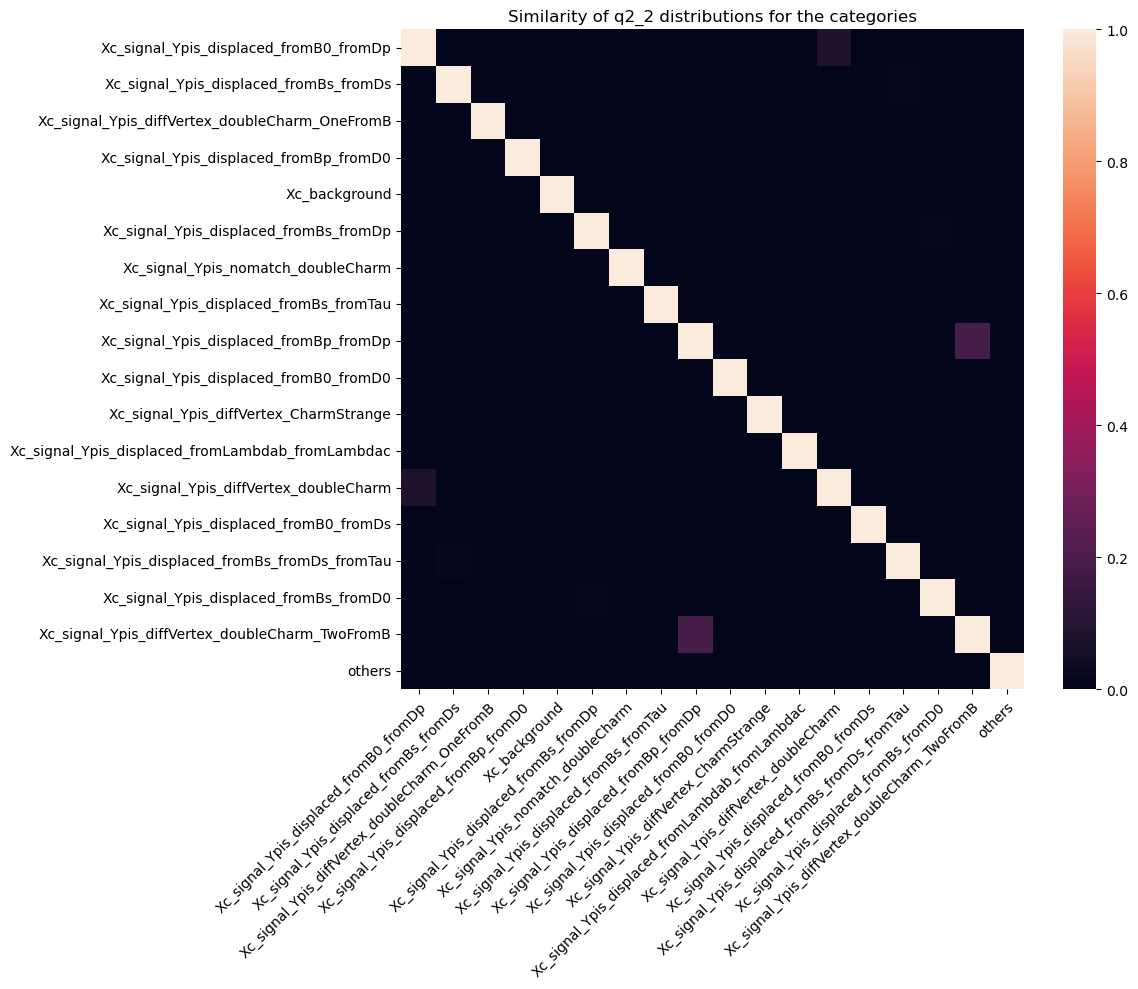

In [10]:
plt.rcParams["figure.figsize"] = (12, 10)
plt.figure()
sn.heatmap(disp_sq2_2)
plt.title("Similarity of q2_2 distributions for the categories");
plt.ylabel("")
plt.xticks(rotation = 45, ha='right', rotation_mode='anchor') 
plt.tight_layout()
plt.savefig("similarity_sq2_2.png",  bbox_inches="tight")

In [11]:
from pprint import pprint
clusters = find_and_merge_clusters(sq2_2, 0.1)
pprint(clusters)
clusters_q2_2 = clusters

[['0'],
 ['14'],
 ['24'],
 ['27'],
 ['21'],
 ['29'],
 ['22'],
 ['20'],
 ['18'],
 ['15', '23'],
 ['25'],
 ['others'],
 ['26'],
 ['13'],
 ['16'],
 ['19'],
 ['7']]


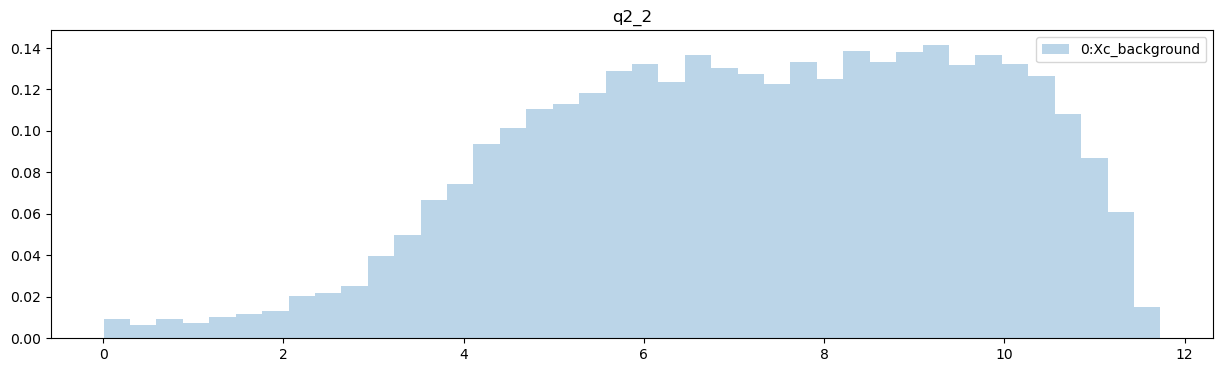

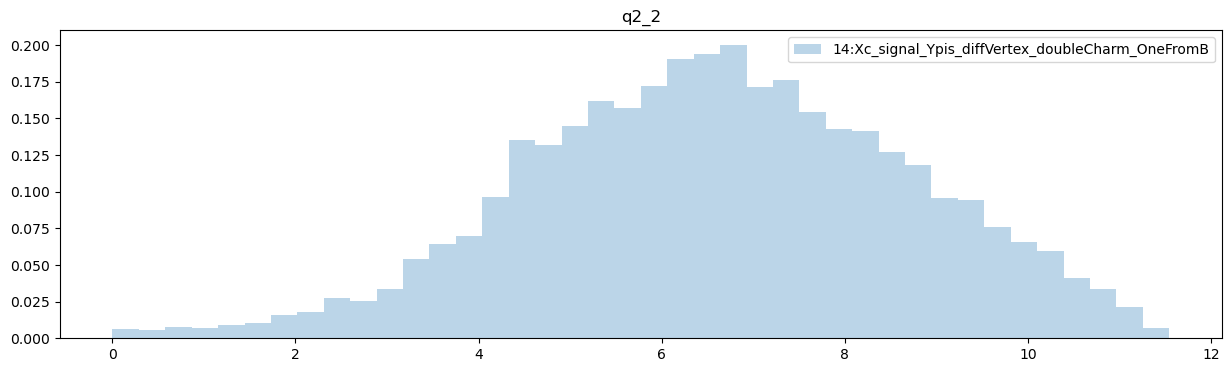

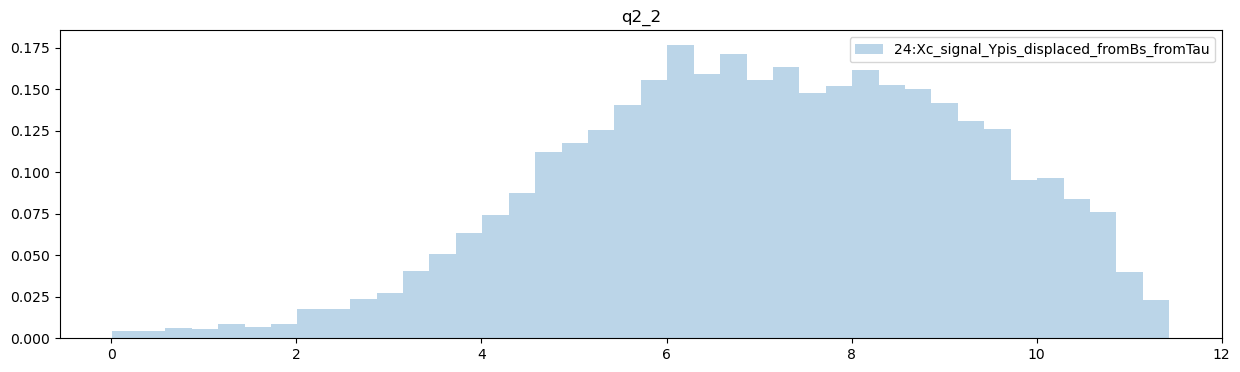

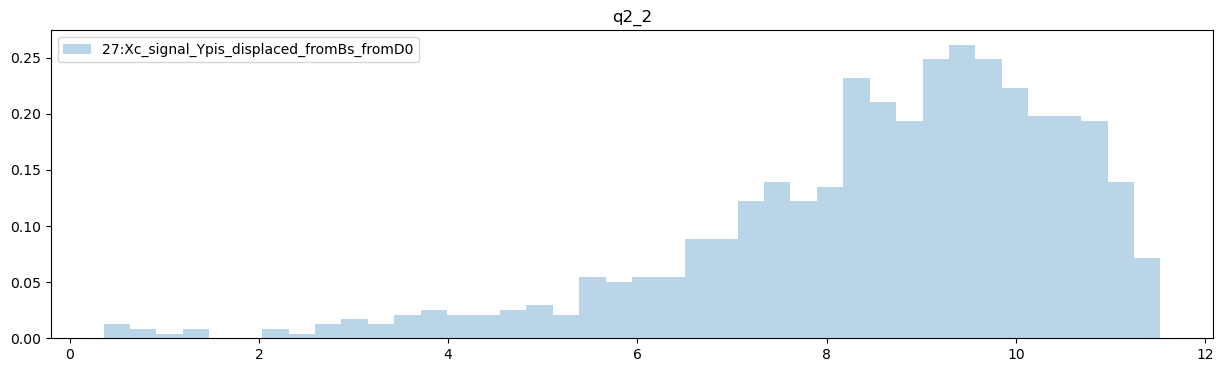

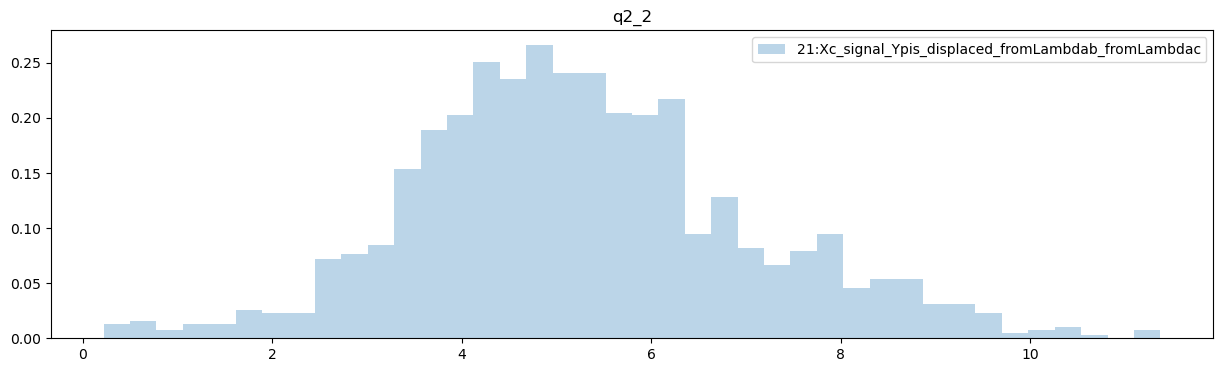

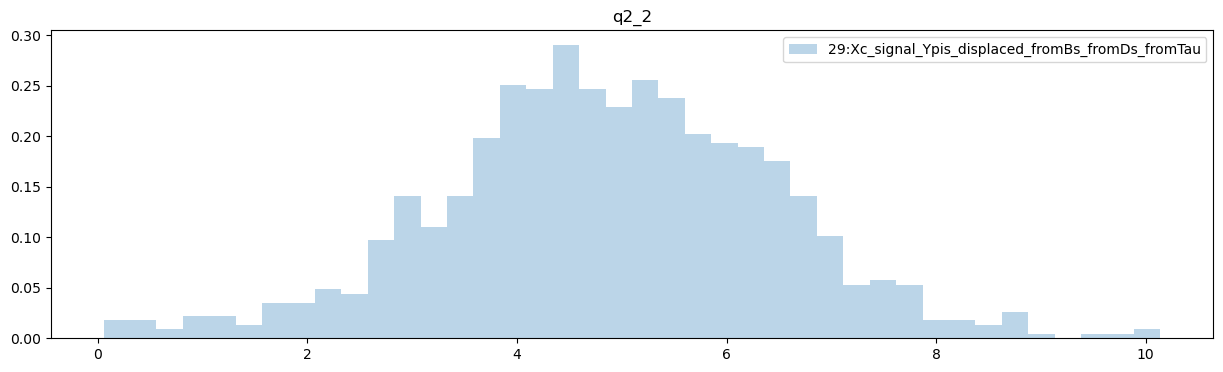

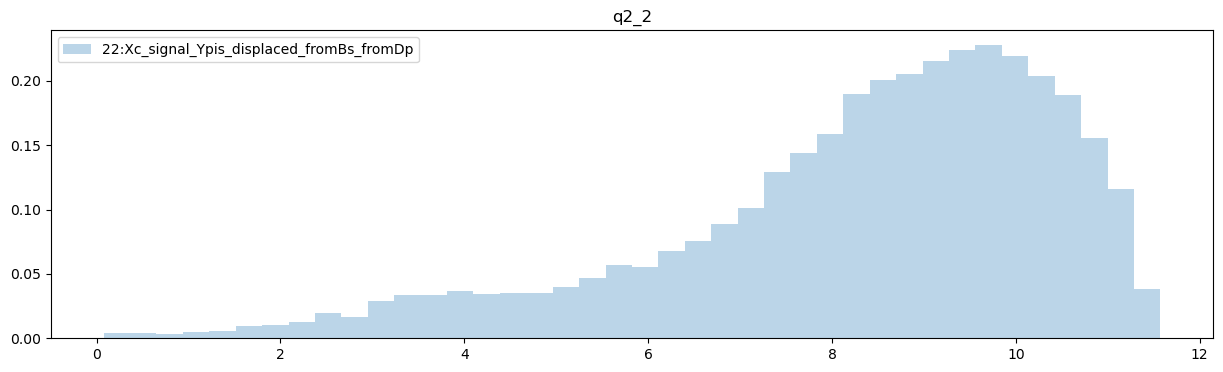

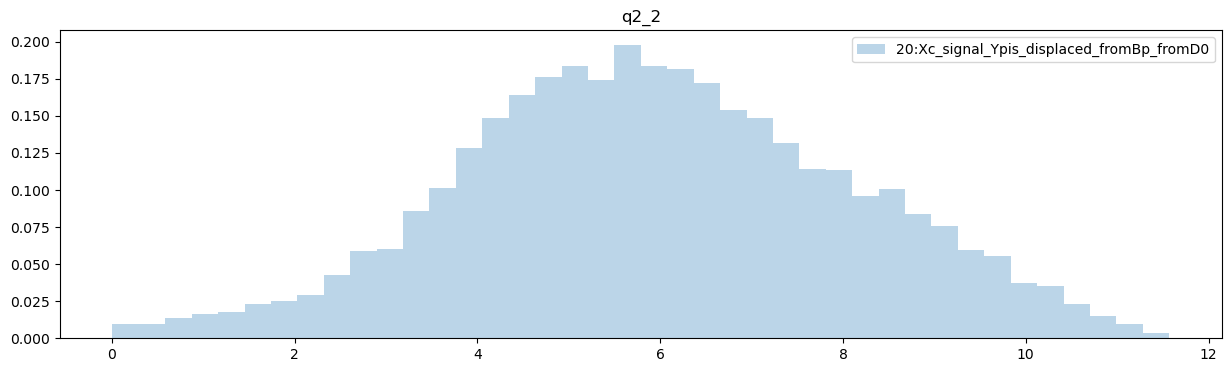

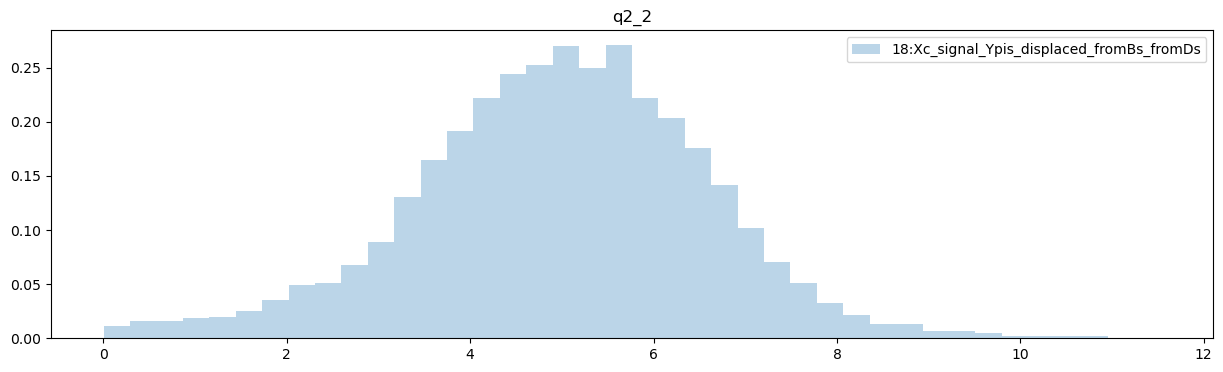

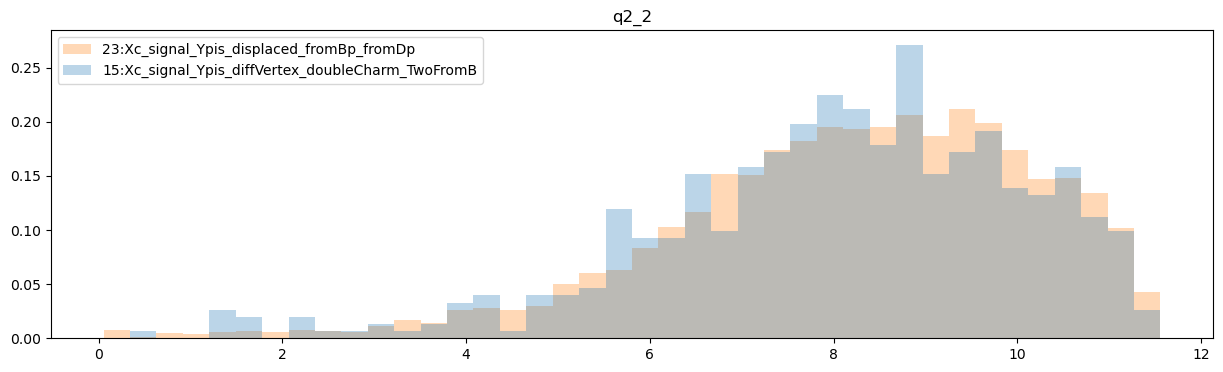

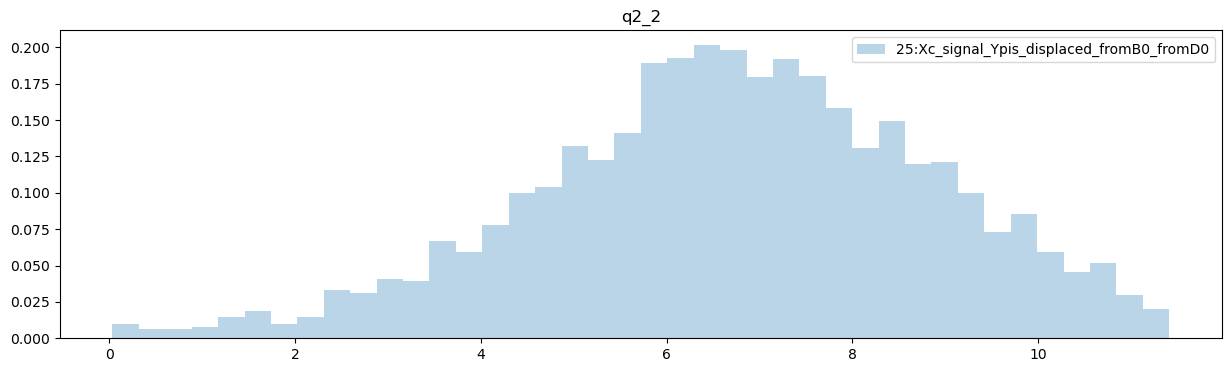

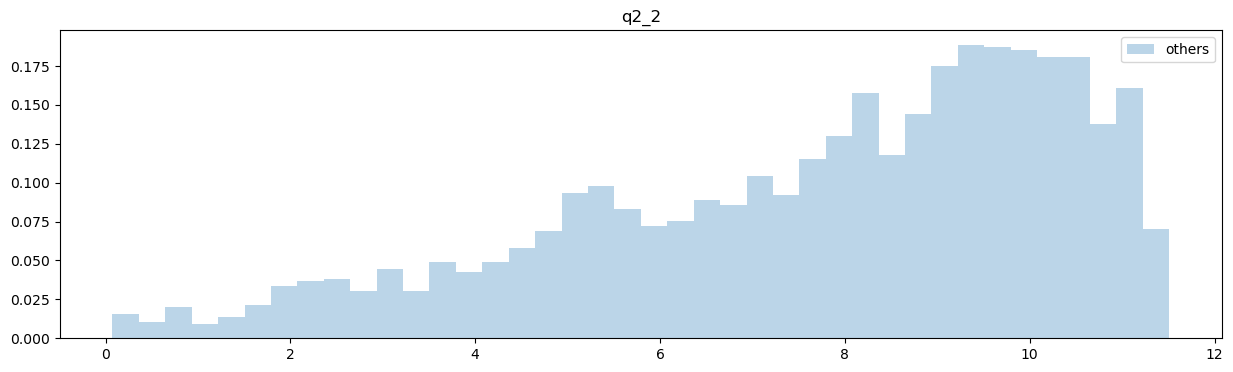

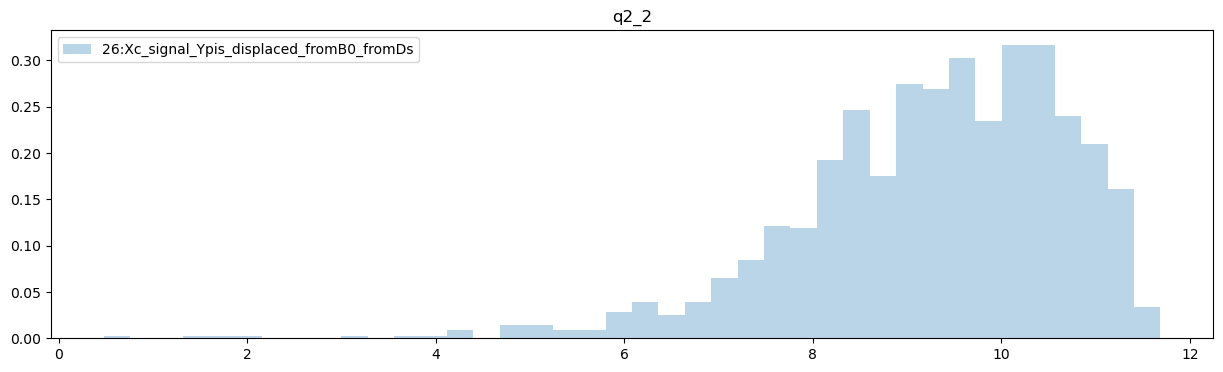

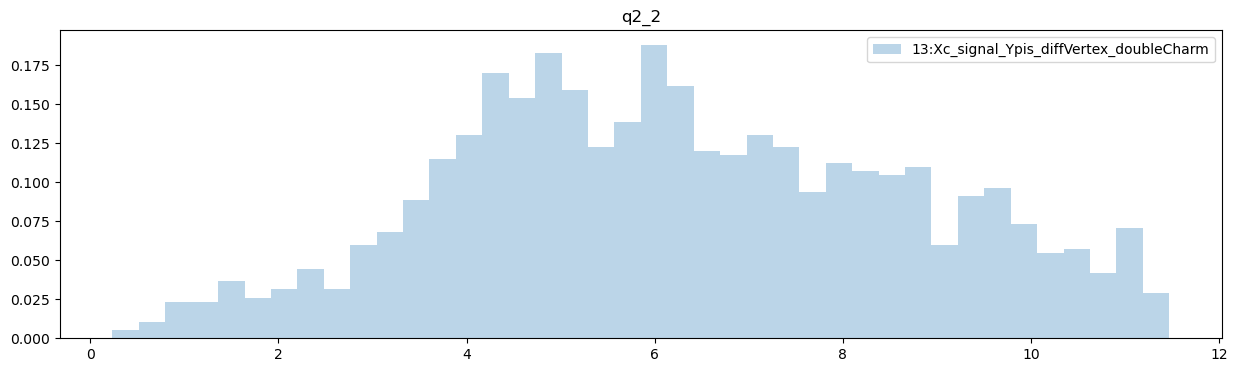

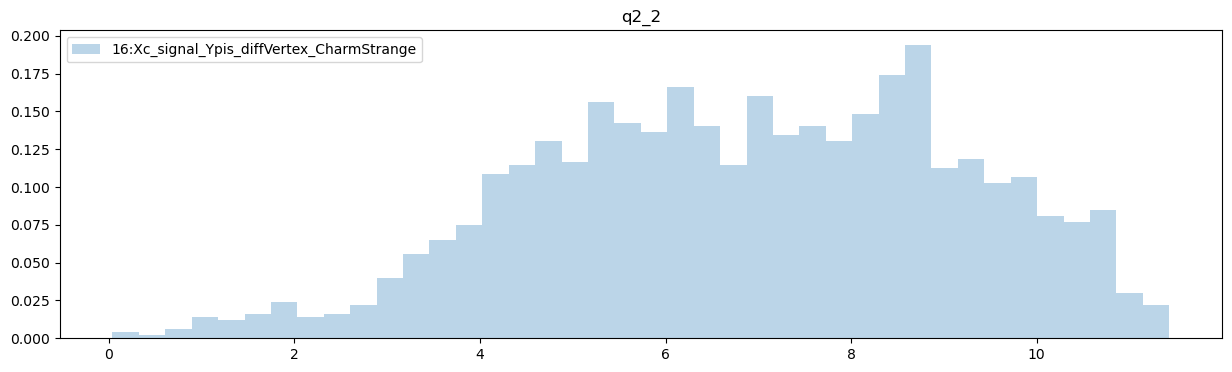

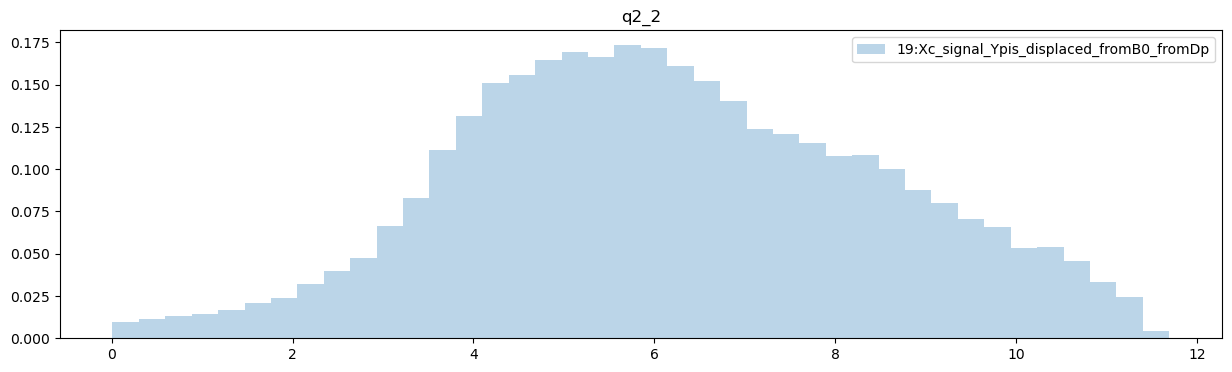

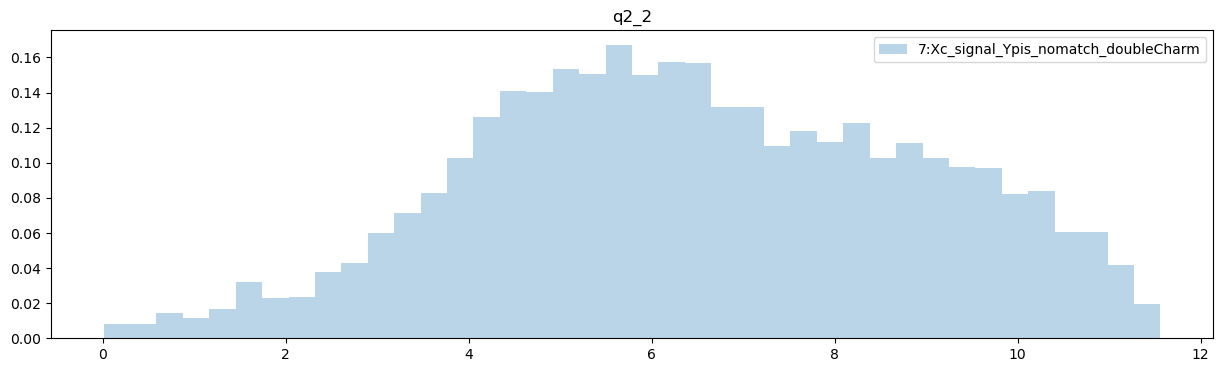

In [12]:
plt.rcParams["figure.figsize"] = (15,4)
for c in clusters:
    plt.figure()
    plot_templates_categs(c, 'q2_2')

## Checking tauY_2 distributions

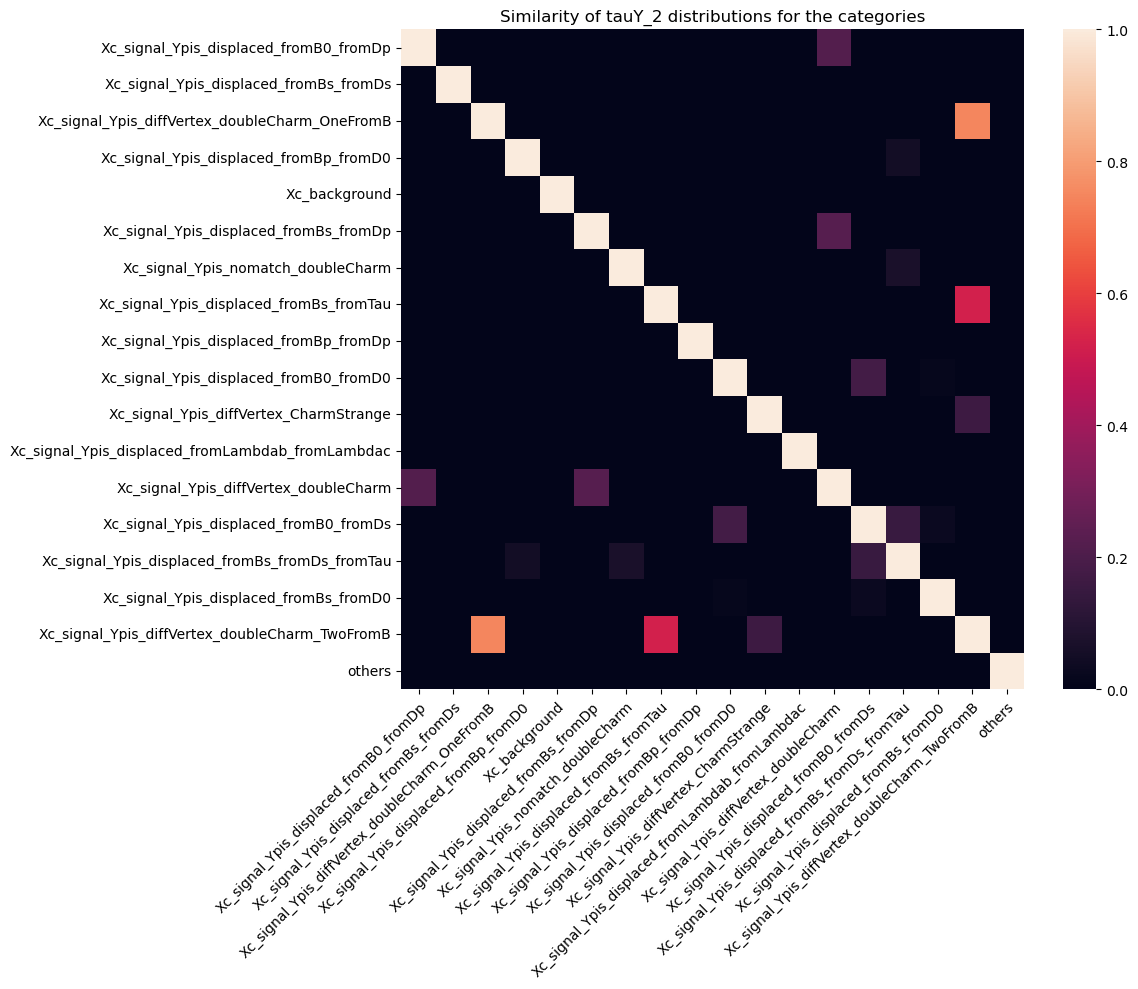

In [13]:
plt.rcParams["figure.figsize"] = (12, 10)
plt.figure()
disp_stauY_2 = stauY_2.copy()
disp_stauY_2.rename(categories, axis=1, inplace=True)
disp_stauY_2.rename(categories, axis=0, inplace=True)
plt.title("Similarity of tauY_2 distributions for the categories");
sn.heatmap(disp_stauY_2)
plt.ylabel("")
plt.xticks(rotation = 45, ha='right', rotation_mode='anchor') 
plt.tight_layout()
plt.savefig("similarity_stauY_2.png",  bbox_inches="tight")



In [14]:
from pprint import pprint
clusters = find_and_merge_clusters(stauY_2, 0.1)
pprint(clusters)

clusters_tauY_2 = clusters

[['0'],
 ['27'],
 ['23'],
 ['21'],
 ['20'],
 ['18'],
 ['26', '29', '25'],
 ['24', '16', '14', '15'],
 ['others'],
 ['19', '13', '22'],
 ['7']]


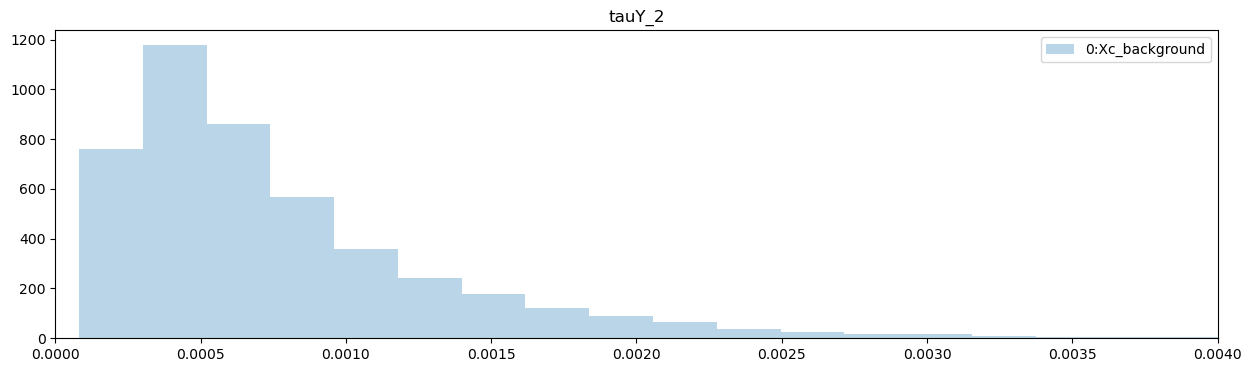

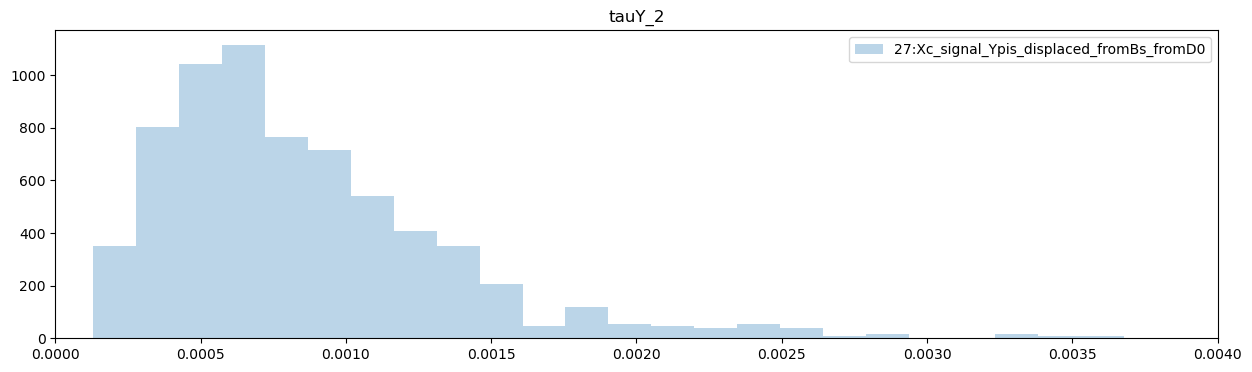

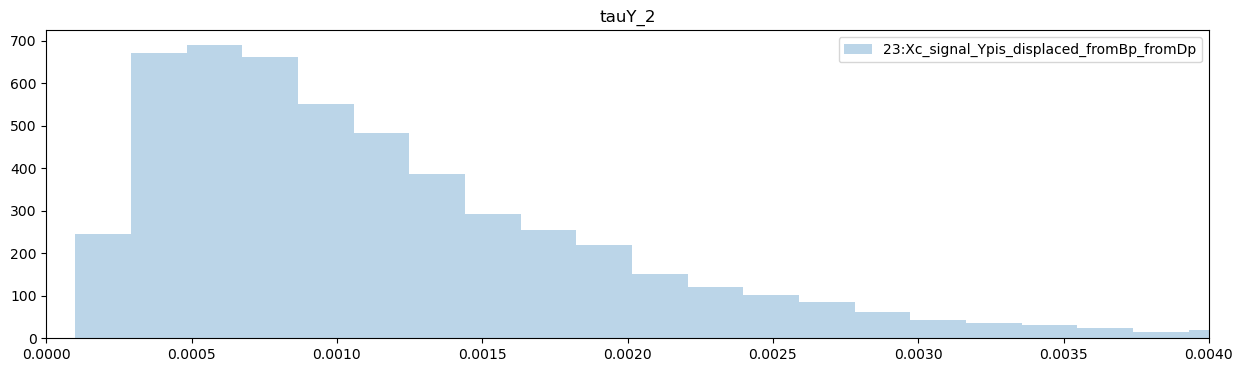

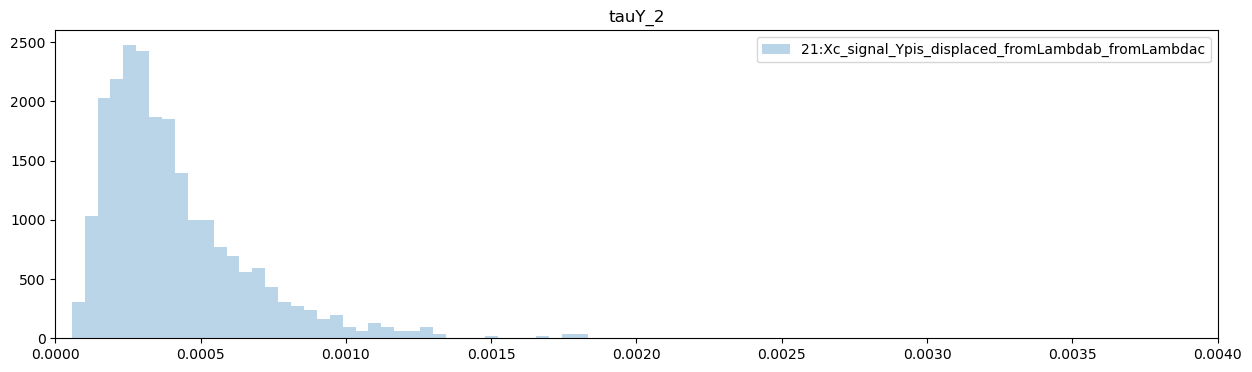

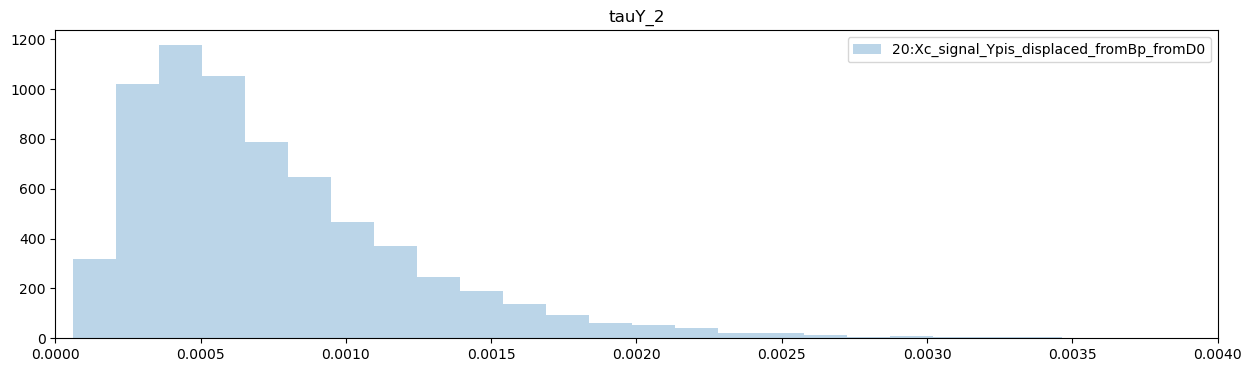

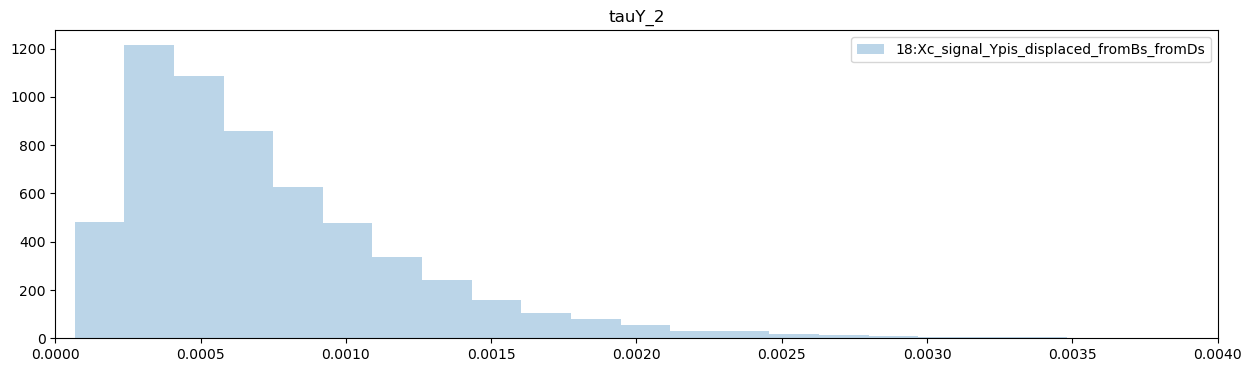

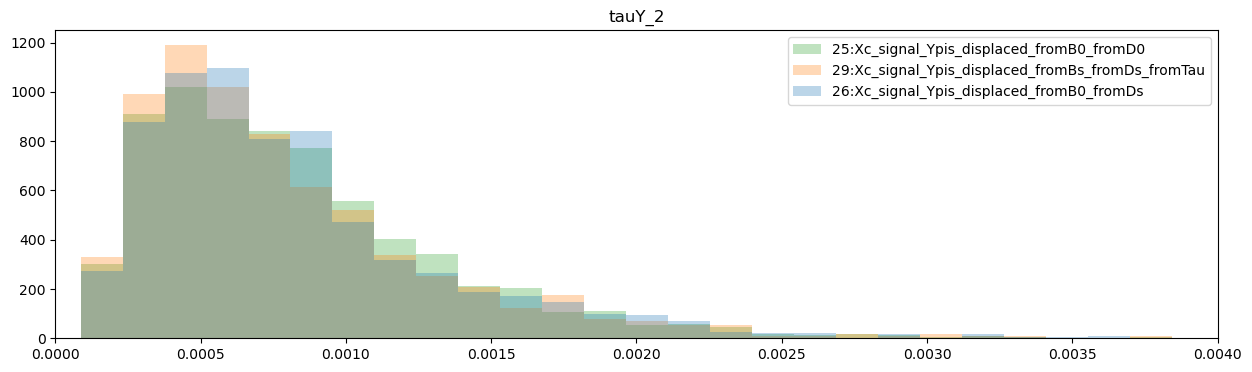

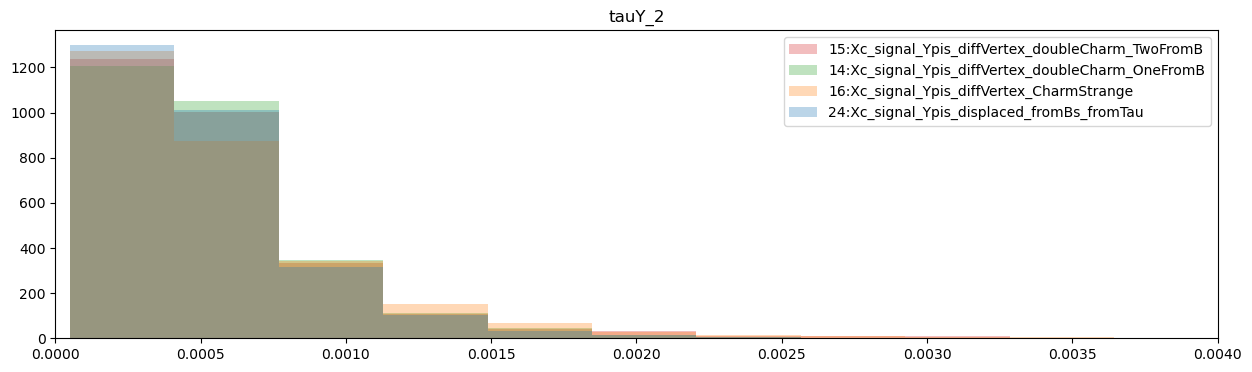

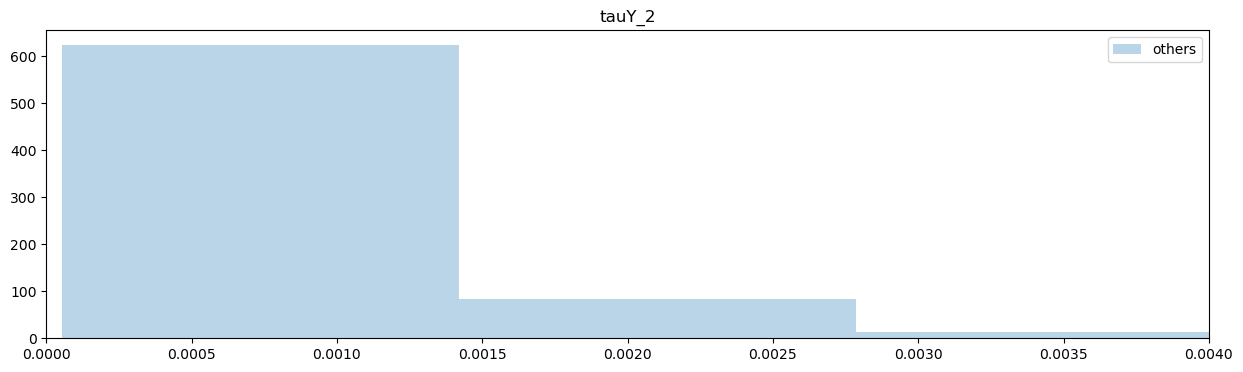

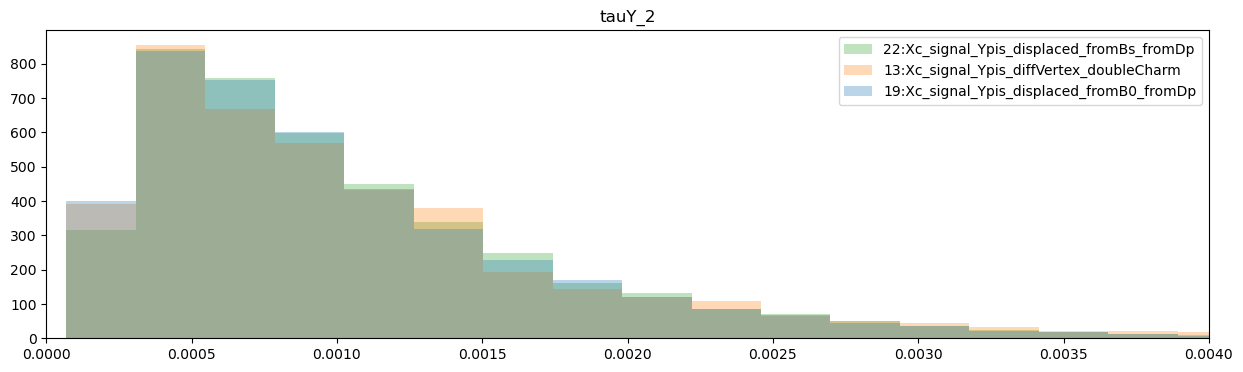

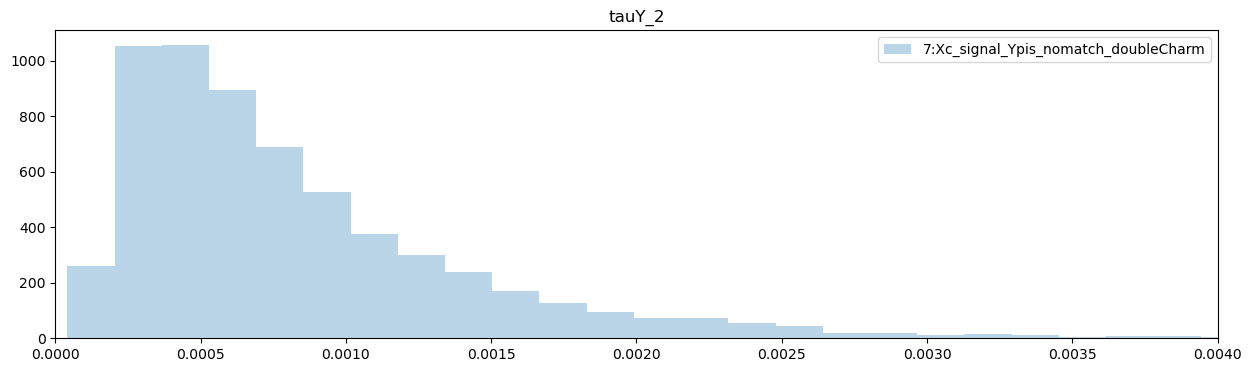

In [15]:
plt.rcParams["figure.figsize"] = (15,4)
for c in clusters:
    plt.figure()
    plot_templates_categs(c, 'tauY_2')

## Checking bdt_all distributions

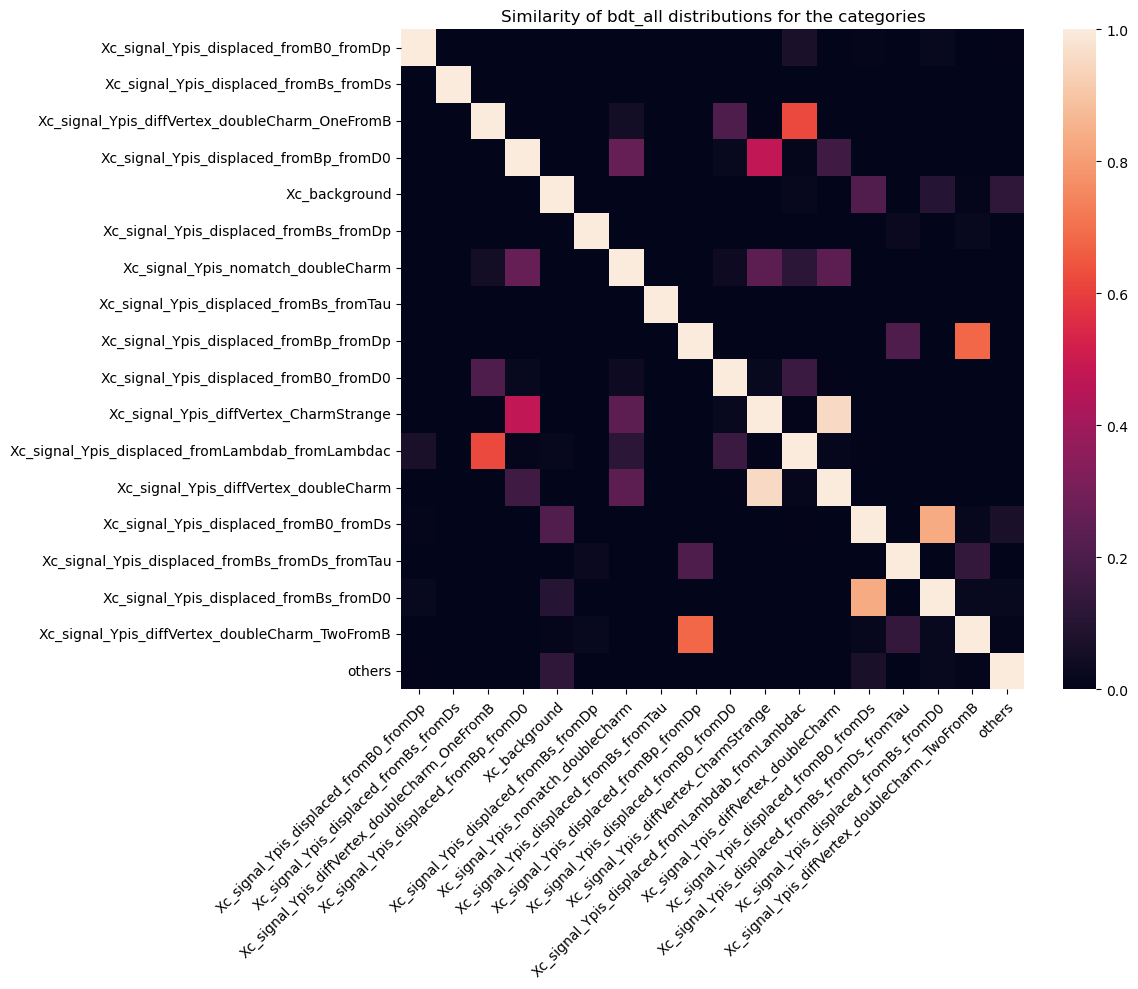

In [16]:
plt.rcParams["figure.figsize"] = (12, 10)
plt.figure()
disp_sbdt_all = sbdt_all.copy()
disp_sbdt_all.rename(categories, axis=1, inplace=True)
disp_sbdt_all.rename(categories, axis=0, inplace=True)
sn.heatmap(disp_sbdt_all)
plt.title("Similarity of bdt_all distributions for the categories");
plt.ylabel("")
plt.xticks(rotation = 45, ha='right', rotation_mode='anchor') 
plt.tight_layout()
plt.savefig("similarity_sbdt_all_2.png",  bbox_inches="tight")

In [17]:
from pprint import pprint
clusters = find_and_merge_clusters(sbdt_all, 0.5)
pprint(clusters)

clusters_bdt_all = clusters

[['0'],
 ['24'],
 ['26', '27'],
 ['22'],
 ['20'],
 ['18'],
 ['15', '23'],
 ['14', '21'],
 ['25'],
 ['others'],
 ['13', '16'],
 ['29'],
 ['19'],
 ['7']]


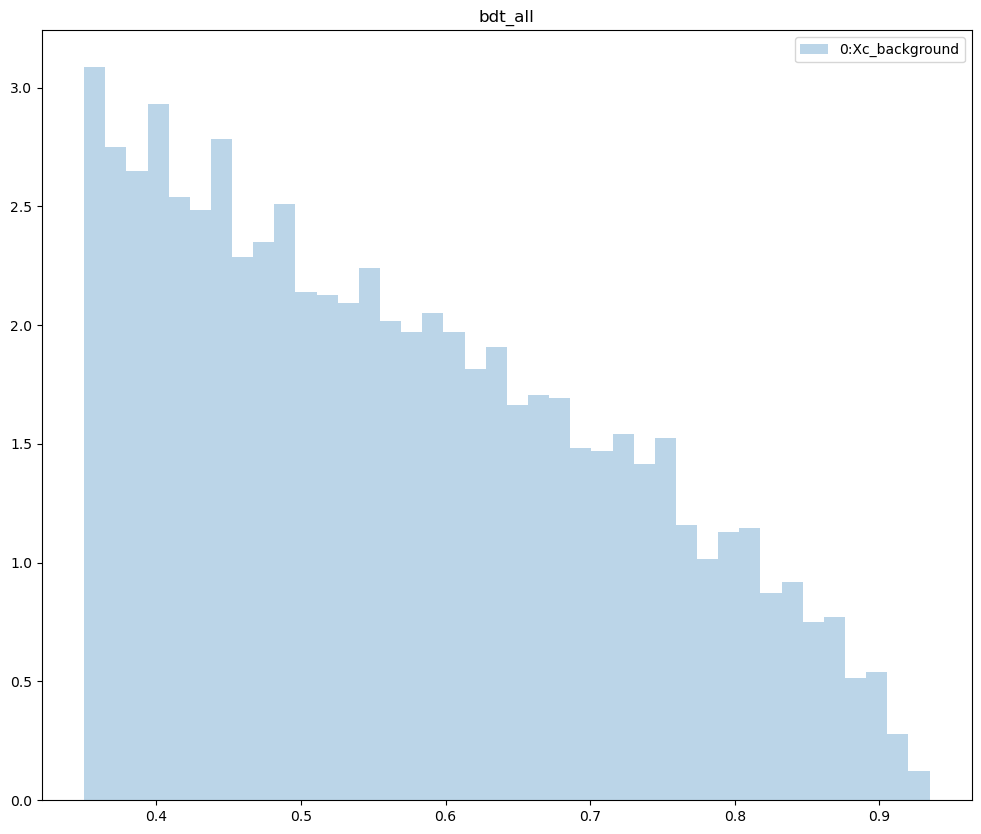

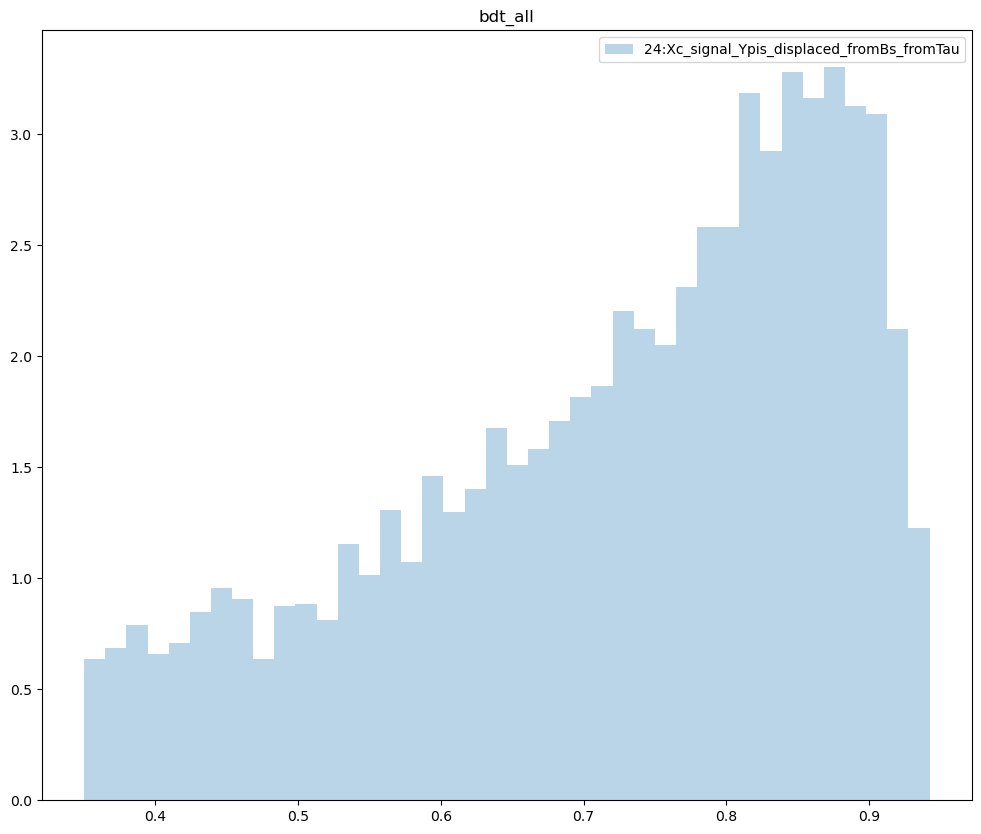

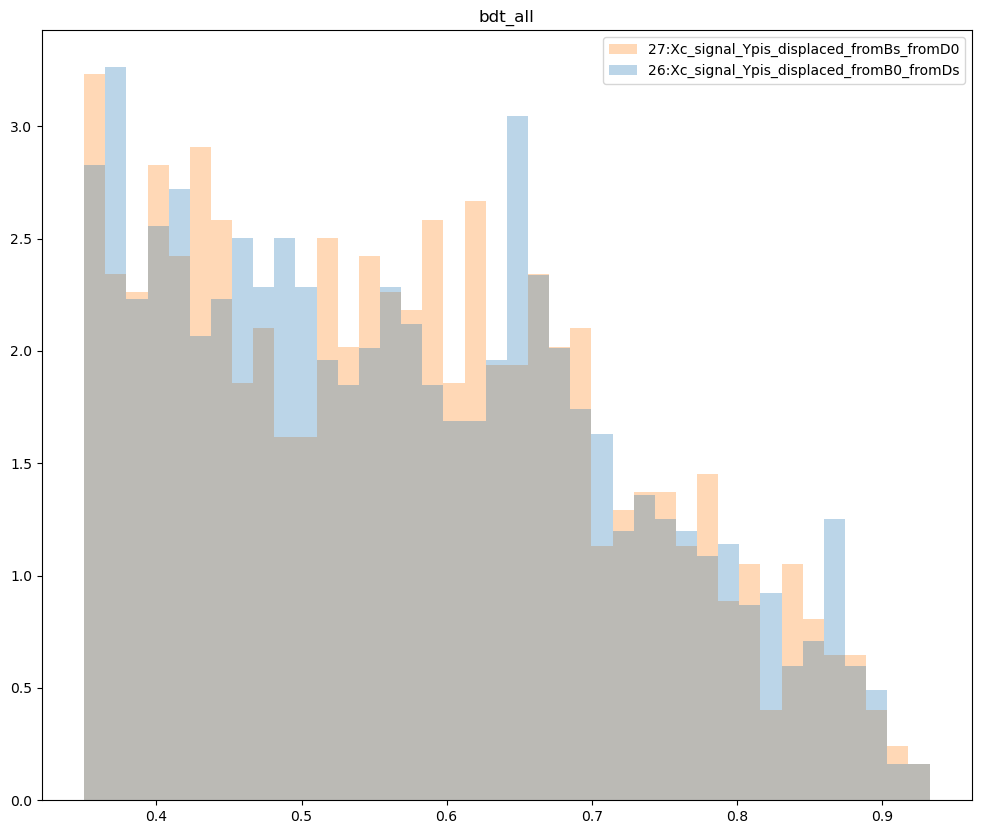

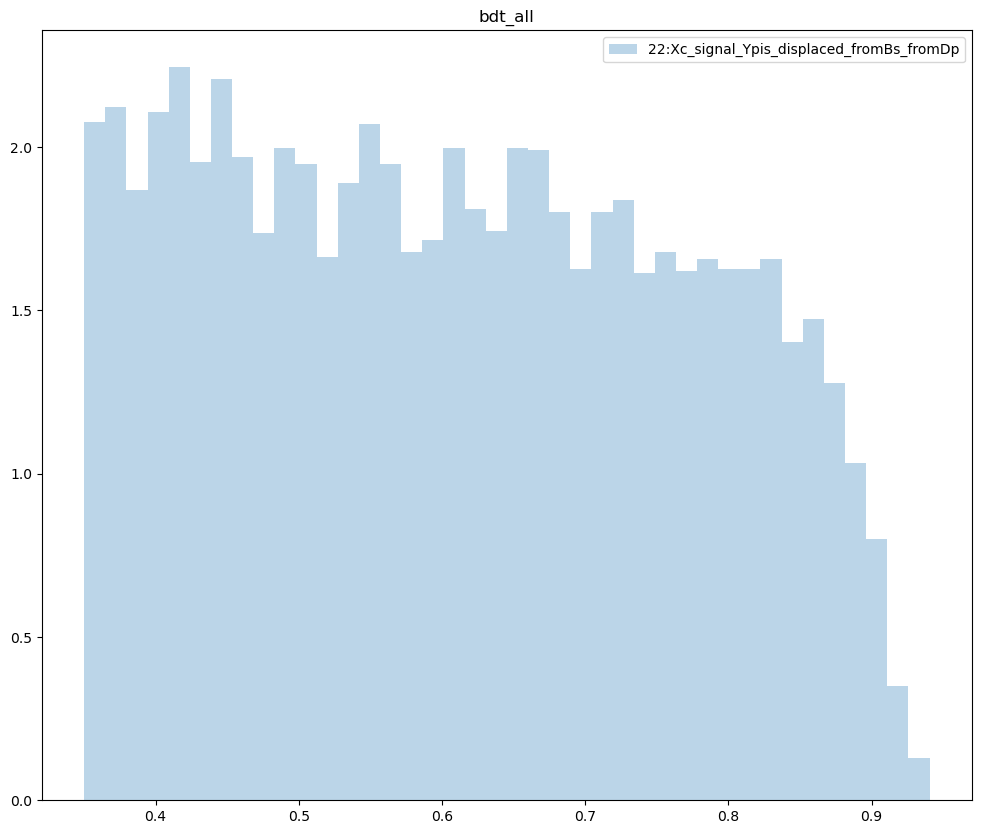

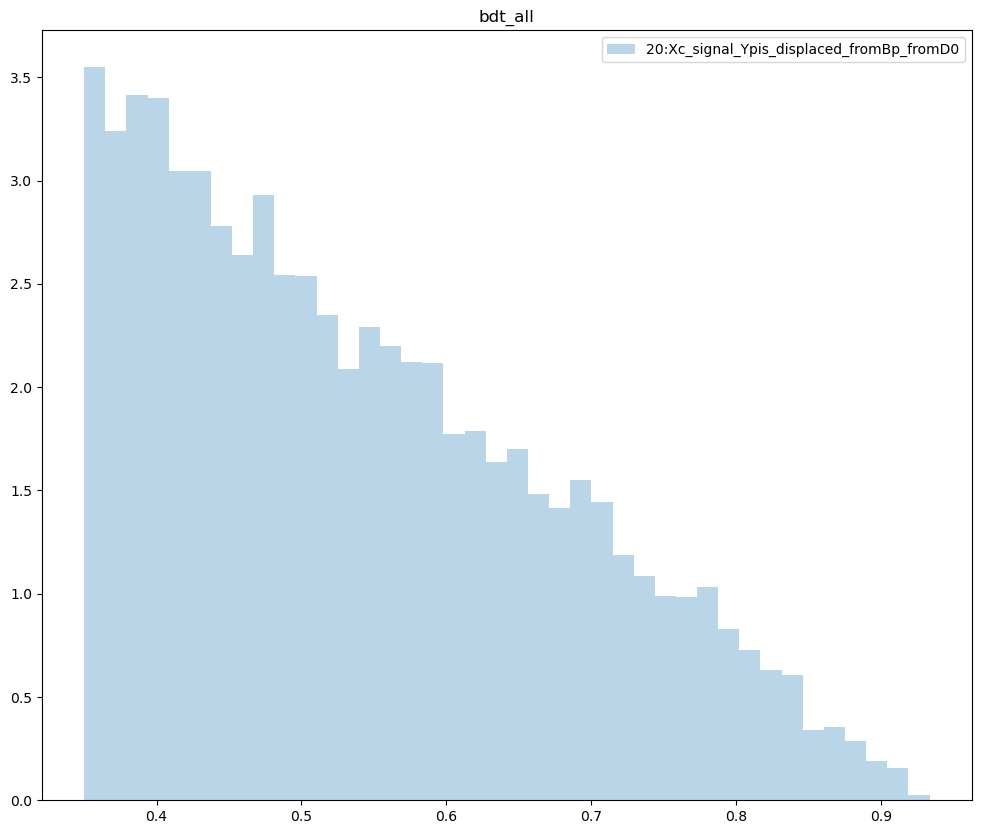

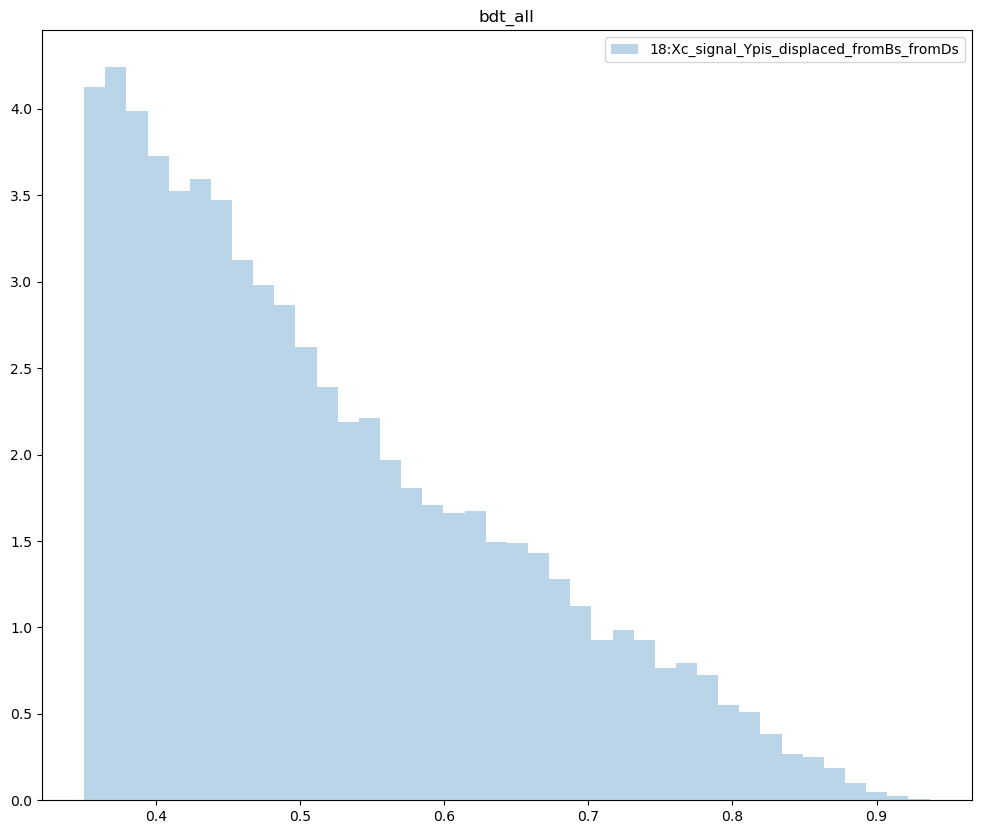

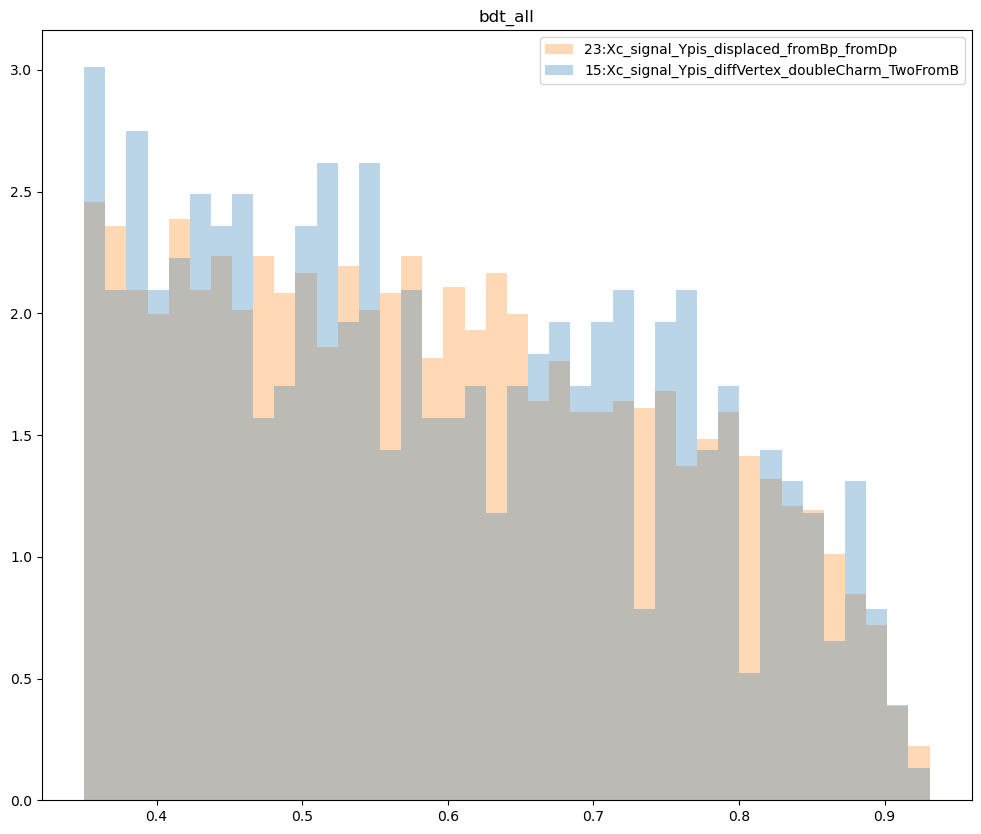

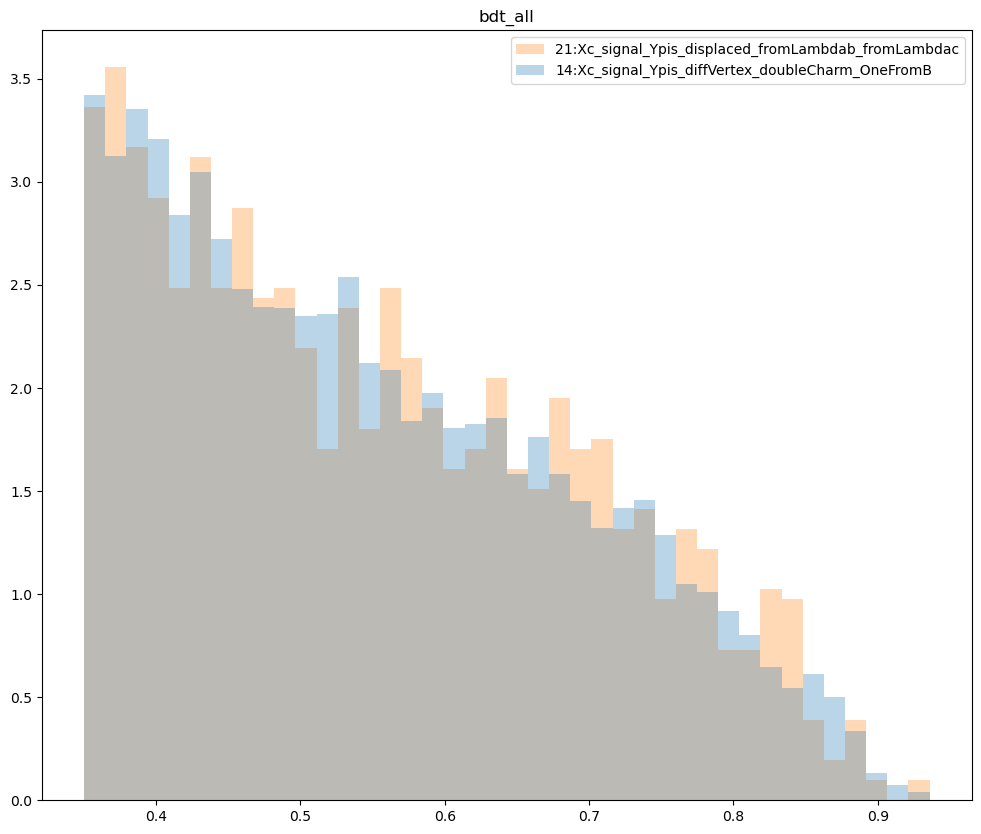

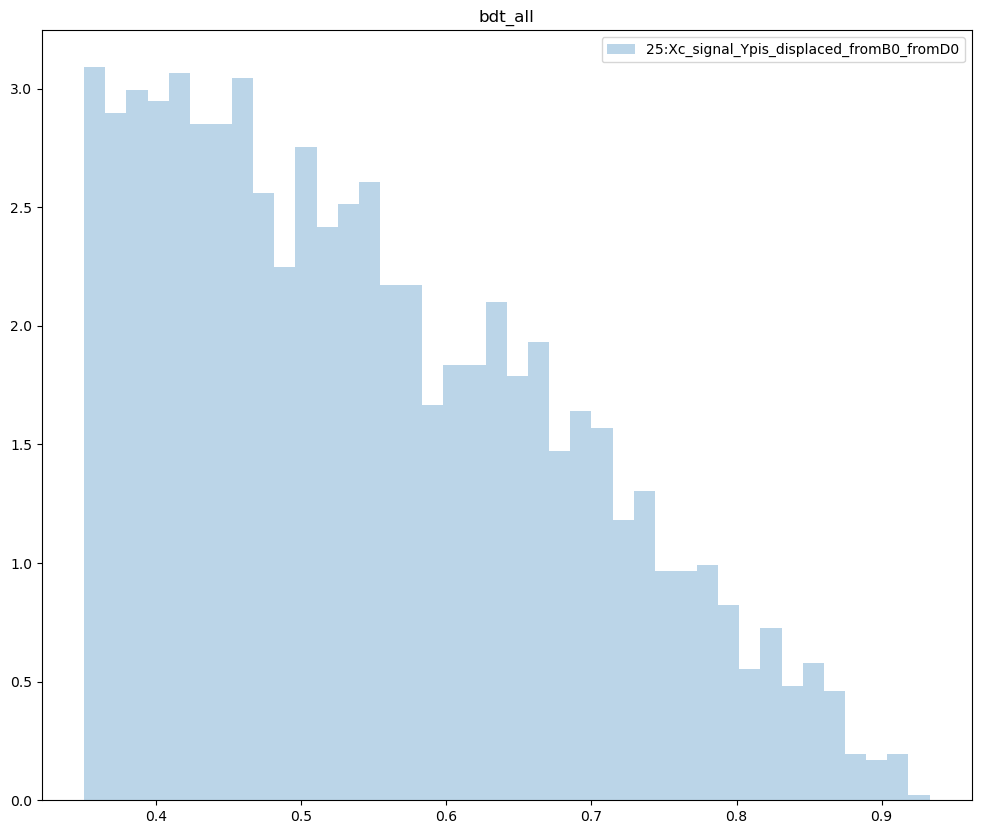

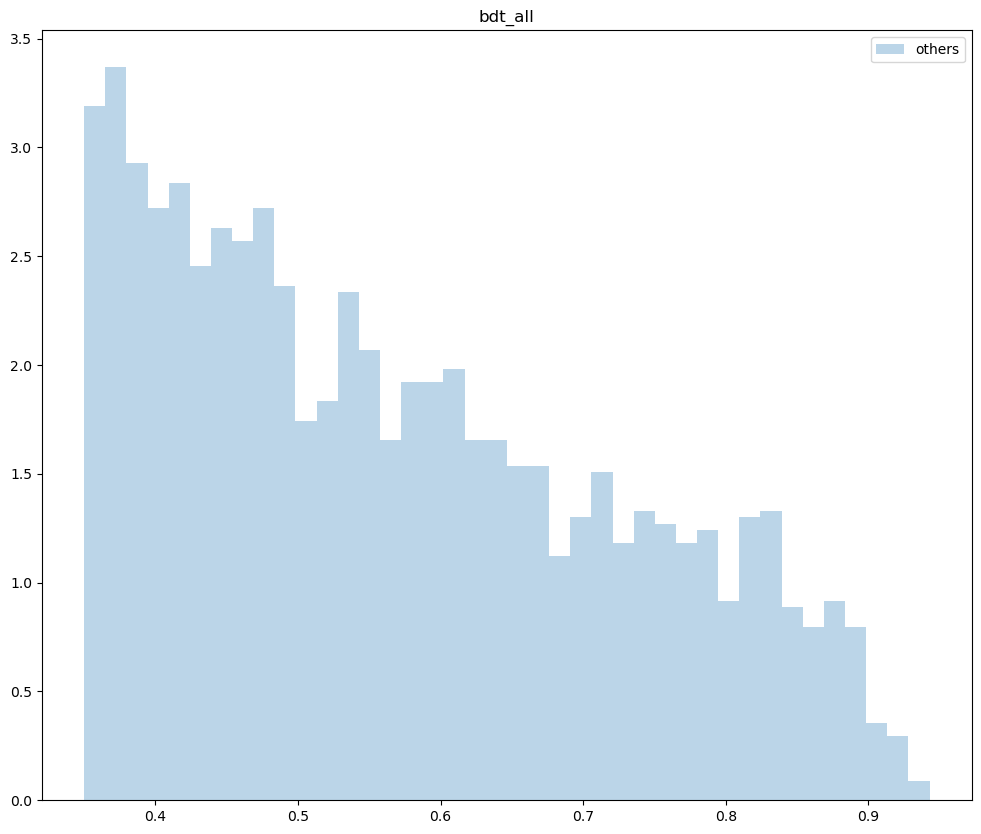

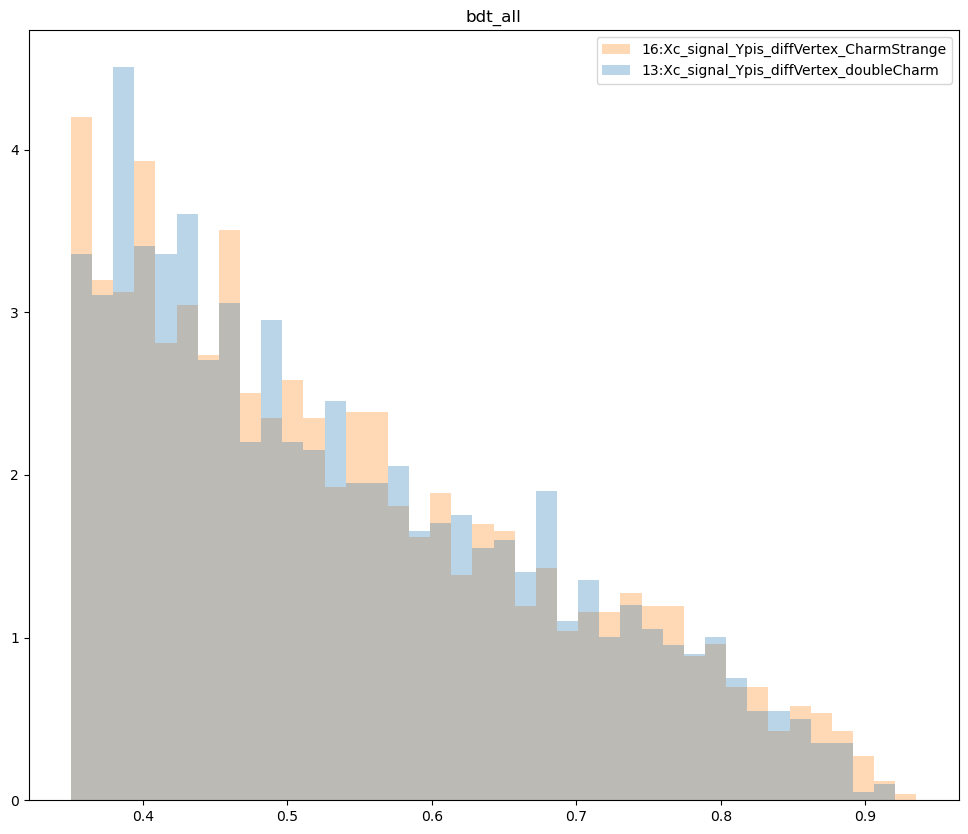

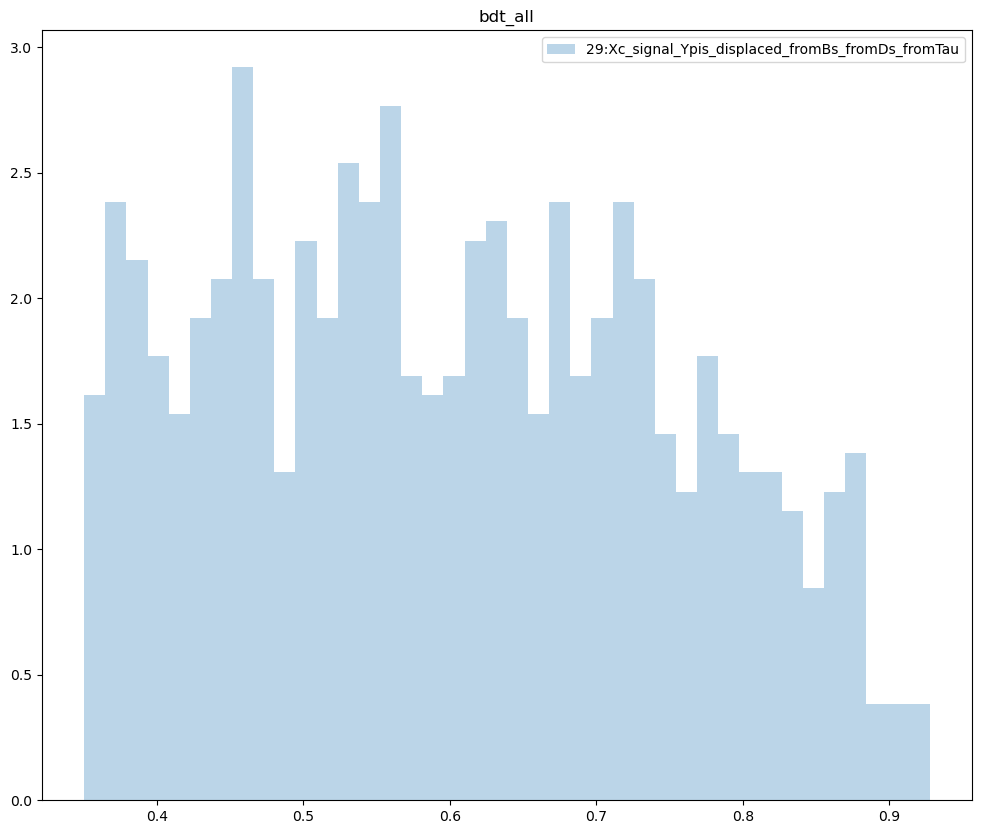

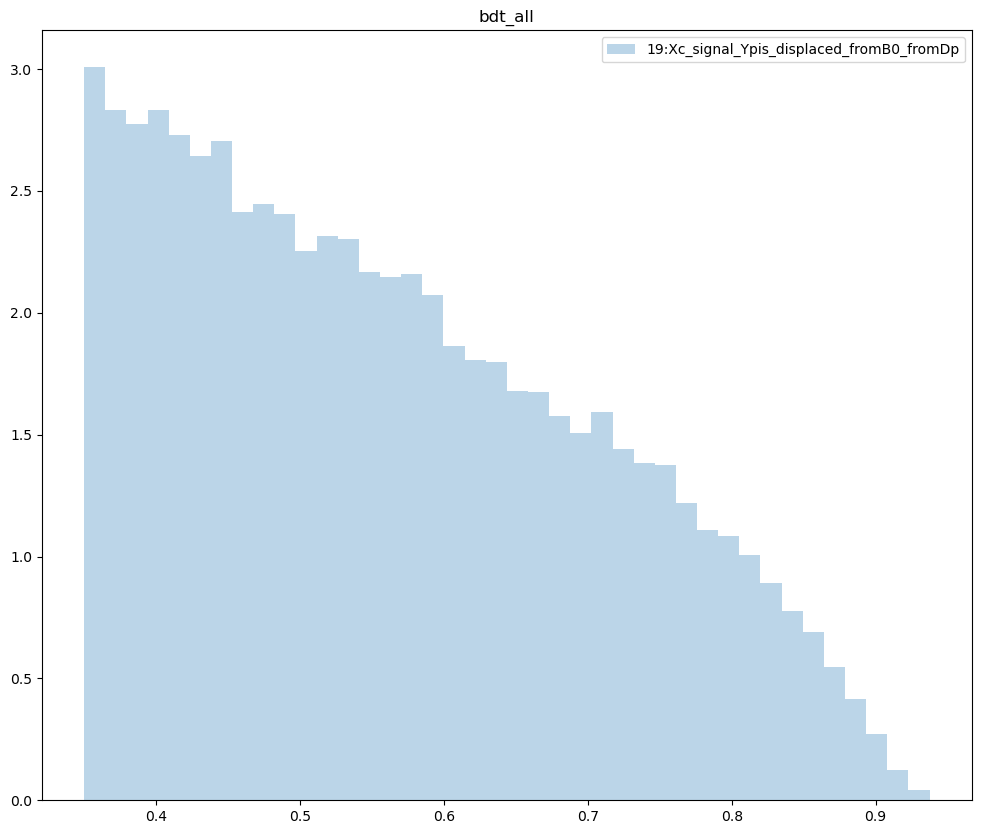

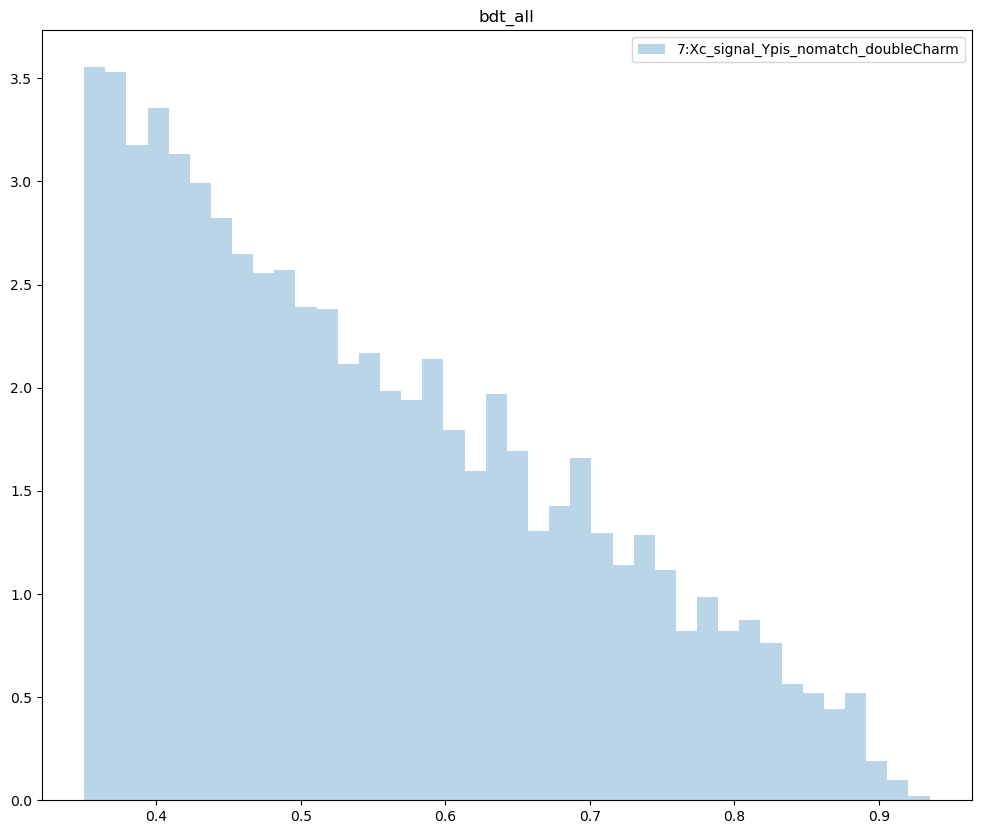

In [18]:
for c in clusters:
    plt.figure()
    plot_templates_categs(c, 'bdt_all')

In [19]:
clusters_bdt_all

[['0'],
 ['24'],
 ['26', '27'],
 ['22'],
 ['20'],
 ['18'],
 ['15', '23'],
 ['14', '21'],
 ['25'],
 ['others'],
 ['13', '16'],
 ['29'],
 ['19'],
 ['7']]